# Agents sharing what they see

> Agents moving in a continuous world exchange latents; what arrives depends on the channel and on where they are.

Six agents move around a 60 × 60 m area. At every step, each one sends a 32-number latent (8 bits per number) to
the agents within its radio range. In multi-agent learning this could be a world model's latent, an observation
embedding or an intention. The same traffic runs over three channels:

* **perfect:** `IdentityChannel`.
* **30% packet loss:** `AWGNChannel`, losses independent of everything.
* **radio:** `SystemLevelChannel`. 1 mW transmitters, path loss growing with distance, Rayleigh fading, and noise
  at −94 dBm.

comm-core does not move the agents. The application does, and tells the channel and the topology where they are
(see [design principles](../principles.ipynb)).

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np

from comm_core import *

In [ ]:
class PathLoss(Fading):
    "Log-distance path loss with Rayleigh fading: |h|^2 = gain_1m / d^exponent x |CN(0, 1)|^2, from the nodes' positions."

    def __init__(self, exponent=3.0, gain_1m=1e-4, rayleigh=True, seed=None):
        self.exponent, self.gain_1m, self.rayleigh = exponent, gain_1m, rayleigh
        self.positions, self.rng = {}, np.random.default_rng(seed)

    def set_positions(self, positions):
        self.positions.update({k: np.asarray(v, float) for k, v in positions.items()})

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

    def coefficient(self, transmission, link):
        d = max(np.linalg.norm(self.positions[transmission.sender] - self.positions[transmission.receiver]), 0.1)
        h = math.sqrt(self.gain_1m / d ** self.exponent)
        if self.rayleigh:
            h *= complex(self.rng.standard_normal(), self.rng.standard_normal()) / math.sqrt(2)
        return h

In [ ]:
AGENTS = [f'agent_{i}' for i in range(6)]
LATENT_BITS = 32 * 8

def simulate(channel, steps=300, seed=0, radius=45.0):
    "Agents on random walks; every step, a latent to every agent within `radius`. Returns per-transmission records."
    rng = np.random.default_rng(seed)
    pos = {a: rng.uniform(0, 60, 2) for a in AGENTS}
    records, heard = [], []
    for step in range(steps):
        for a in AGENTS:                                                  # the application moves the agents
            pos[a] = np.clip(pos[a] + rng.normal(0, 1.0, 2), 0, 60)
        if hasattr(channel, 'set_positions'):
            channel.set_positions(pos)
        topology = DistanceTopology(pos, radius=radius, tx_power_w=1e-3)  # who is in range, now (1 mW links)
        net = Network([Node(a) for a in AGENTS], topology, IdealProtocol(), AnalyticalBackend(channel))
        for s in AGENTS:
            for r in topology.neighbors(s):
                net.send(Message(s, r, payload=None, type='latent', size_bits=LATENT_BITS))
        for res in net.step():
            t = res.transmission
            records.append((np.linalg.norm(pos[t.sender] - pos[t.receiver]), res.success))
        heard.append(np.mean([len(net.receive(a)) for a in AGENTS]))
    return np.array(records), np.array(heard)

channels = {
    'perfect': IdentityChannel(),
    '30% packet loss': AWGNChannel(snr_db=5, packet_error_rate=0.3, seed=0),
    'radio': SystemLevelChannel(fading=PathLoss(seed=0), noise_power=10 ** ((-94 - 30) / 10), seed=0),
}
results = {name: simulate(ch) for name, ch in channels.items()}
for name, (records, heard) in results.items():
    print(f'{name:16s} {records[:, 1].mean():.0%} of the latents delivered; an agent hears {heard.mean():.1f} others per step')

perfect          100% of the latents delivered; an agent hears 3.3 others per step
30% packet loss  71% of the latents delivered; an agent hears 2.4 others per step
radio            67% of the latents delivered; an agent hears 2.2 others per step


The radio links fail with distance and fade at random. The fixed-loss channel loses the same share everywhere,
which a learner can average out. Losses that depend on where the agents are cannot be averaged out that way:

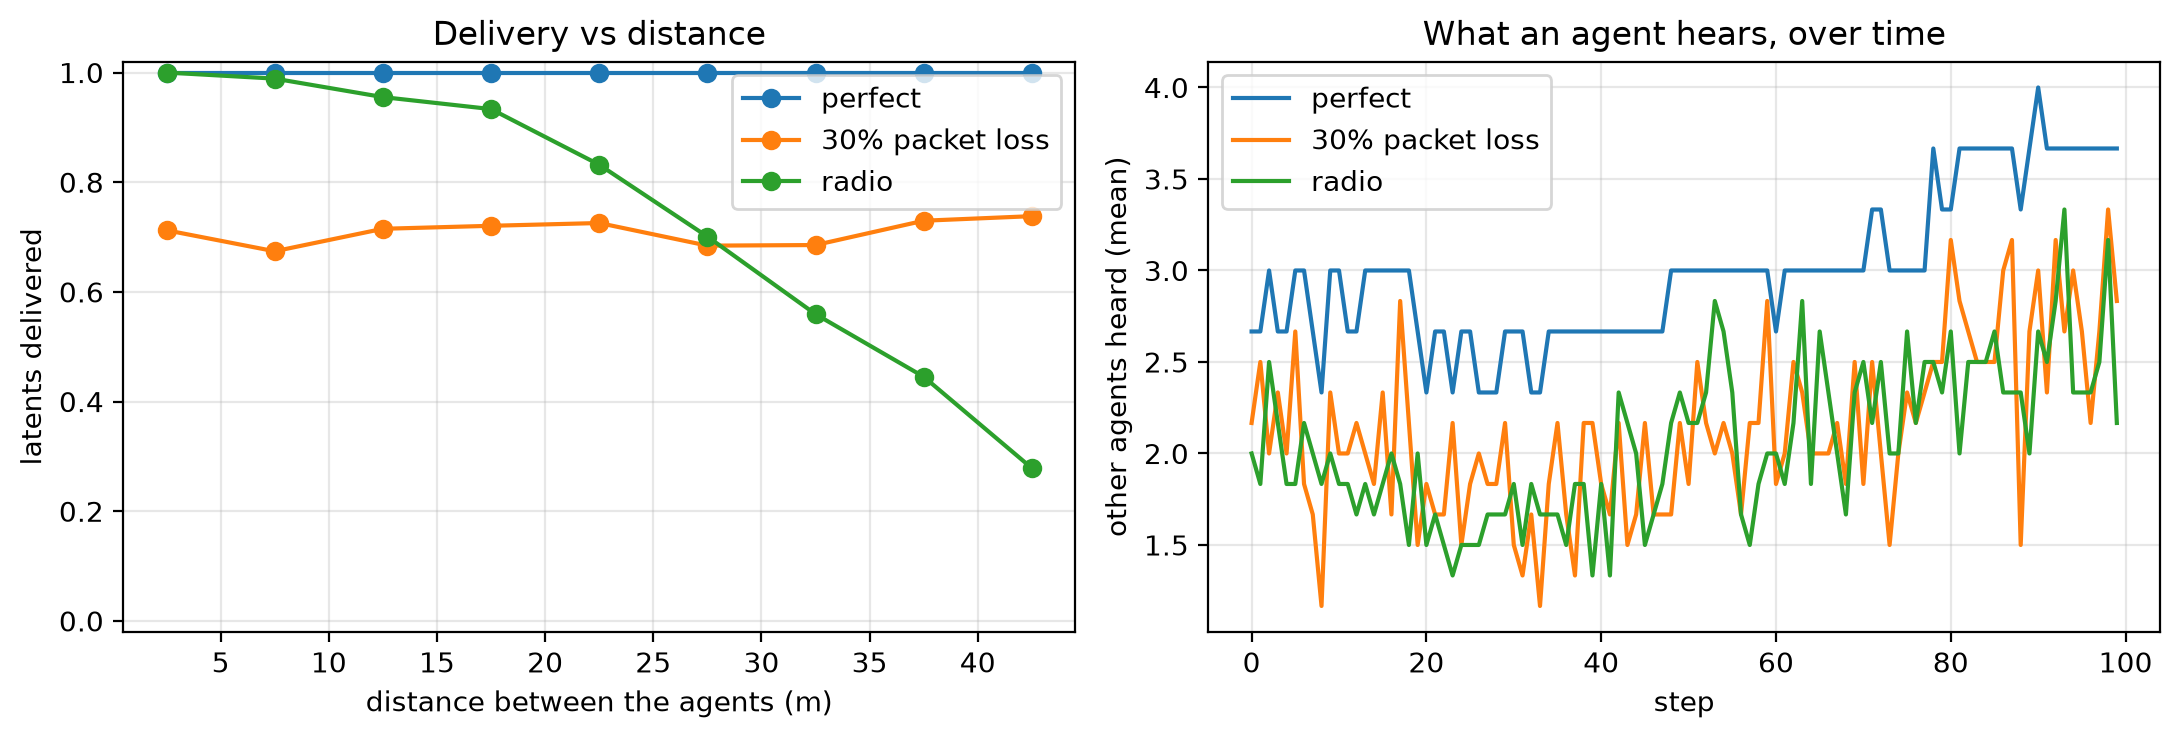

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.arange(0, 50, 5)
for name, (records, heard) in results.items():
    d, ok = records[:, 0], records[:, 1]
    centers = (bins[:-1] + bins[1:]) / 2
    rate = [ok[(d >= lo) & (d < hi)].mean() if ((d >= lo) & (d < hi)).any() else np.nan for lo, hi in zip(bins[:-1], bins[1:])]
    axes[0].plot(centers, rate, 'o-', label=name)
    axes[1].plot(heard[:100], label=name)
axes[0].set(xlabel='distance between the agents (m)', ylabel='latents delivered', title='Delivery vs distance', ylim=(-0.02, 1.02))
axes[1].set(xlabel='step', ylabel='other agents heard (mean)', title='What an agent hears, over time')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()

In a learning loop, each agent's input is then built from what it received. Typically that's a fixed-size array
with the latents of the agents heard, zeros for the others, and a mask, which is what stable-marl's
`CommunicationWrapper` puts in the observations:

In [ ]:
channel = channels['radio']
pos = {a: np.array([10.0 * i, 20.0]) for i, a in enumerate(AGENTS)}           # in a row, 10 m apart
channel.set_positions(pos)
net = Network([Node(a) for a in AGENTS], FullMeshTopology(AGENTS), IdealProtocol(), AnalyticalBackend(channel))
latents = {a: np.random.default_rng(i).normal(size=32).astype(np.float32) for i, a in enumerate(AGENTS)}
for s in AGENTS:
    for r in AGENTS:
        if s != r:
            net.send(Message(s, r, payload=latents[s], type='latent', size_bits=LATENT_BITS))
net.step()
inputs, mask = np.zeros((len(AGENTS), 32), np.float32), np.zeros(len(AGENTS), bool)
for m in net.receive('agent_0'):
    j = AGENTS.index(m.sender)
    inputs[j], mask[j] = m.payload, True
print('agent_0 heard:', mask.astype(int), '(agents 10, 20, ..., 50 m away)')
assert mask[1]                                                                  # the nearest one gets through

agent_0 heard: [0 1 1 1 1 1] (agents 10, 20, ..., 50 m away)
